# B6 — Préparation des données images (MVTec AD, catégorie `hazelnut`)

Ce notebook prépare les images pour un auto-encodeur de détection d'anomalies (approche non supervisée : on apprend à reconstruire uniquement des pièces **saines**, et tout ce qui est mal reconstruit devient suspect).

## Étape 1 — Redimensionnement des images

Les images MVTec d'origine (`artifacts/hazelnut`) sont en haute résolution (1024×1024). On les redimensionne toutes en **256×256** et on les sauvegarde dans `artifacts/hazelnut_resized`, en conservant la structure d'origine :

- `train/good` — pièces saines pour l'entraînement,
- `test/good` — pièces saines pour l'évaluation,
- `test/<défaut>` — pièces défectueuses (crack, cut, hole, print).

On utilise l'interpolation `INTER_AREA`, adaptée à la réduction de taille, et on garde le format BGR d'OpenCV (aucune conversion de couleur nécessaire pour un simple redimensionnement disque-à-disque).

In [ ]:
import shutil
from pathlib import Path

import cv2

DATA_DIR = Path("artifacts/hazelnut")
IMG_SIZE = (256, 256)  # (largeur, hauteur)
DIM = IMG_SIZE[0]  # dimension utilisée pour nommer le dossier et les fichiers
RESIZED_DIR = Path(f"artifacts/hazelnut_resized_{DIM}")


# Log du nombre d'images par dossier (train, test) et sous-dossier
splits = [s for s in ["train", "test"] if (DATA_DIR / s).is_dir()]
counts = {
    split: {
        sub.name: len(list(sub.glob("*.png")))
        for sub in sorted(p for p in (DATA_DIR / split).iterdir() if p.is_dir())
    }
    for split in splits
}
grand_total = sum(sum(c.values()) for c in counts.values())

print(f"Contenu de {DATA_DIR} (total : {grand_total} images) :")
for split in splits:
    total_split = sum(counts[split].values())
    pct_split = total_split / grand_total if grand_total else 0
    print(f"{split} ({total_split} images, {pct_split:.1%} du total) :")
    for name, n in counts[split].items():
        print(f"  {name:<8}: {n} images")
print()


def resize_folder_to_disk(src_dir, dst_dir, size=IMG_SIZE):
    """Redimensionne les images .png de src_dir (couleur) et les écrit dans dst_dir (suffixe _{DIM})."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    paths = sorted(Path(src_dir).glob("*.png"))
    for path in paths:
        img = cv2.imread(str(path))  # BGR (format natif OpenCV, réutilisé tel quel pour imwrite)
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)  # INTER_AREA = réduction de taille
        cv2.imwrite(str(dst_dir / f"{path.stem}_{DIM}{path.suffix}"), img)
    return len(paths)


# On repart d'un dossier propre : suppression de RESIZED_DIR s'il existe
if RESIZED_DIR.exists():
    shutil.rmtree(RESIZED_DIR)
    print(f"Dossier existant supprimé : {RESIZED_DIR}")

total = 0

# Images (couleur) : train/ et test/ uniquement (ground_truth ignoré)
for split in ["train", "test"]:
    for sub in sorted(p for p in (DATA_DIR / split).iterdir() if p.is_dir()):
        n = resize_folder_to_disk(sub, RESIZED_DIR / split / sub.name)
        total += n
        print(f"{split}/{sub.name:<6}: {n} images -> {RESIZED_DIR / split / sub.name}")

print(f"\nTotal : {total} fichiers redimensionnés en {IMG_SIZE[0]}×{IMG_SIZE[1]} dans {RESIZED_DIR}")

In [ ]:
n_resized = len(list(RESIZED_DIR.rglob("*.png")))
print(f"{n_resized} images redimensionnées et sauvegardées dans {RESIZED_DIR}")

## Étape 2 — Pipeline d'augmentation (Albumentations)

On construit un pipeline d'augmentation appliqué **uniquement aux saines d'entraînement** (`train/good`), pour agrandir artificiellement le jeu d'entraînement de l'auto-encodeur :

- **flips** horizontal et vertical,
- **rotations légères** (±15°),
- **translation / échelle** (±5 %, zoom 0.9–1.1) via `Affine`,
- **variations d'éclairage** (luminosité / contraste ±20 %).

Chaque transformation est **nommée** et appliquée individuellement aux **images redimensionnées** (`hazelnut_resized_256/train/good`). Les résultats sont sauvegardés en `.png` dans `artifacts/hazelnut_augmented`, avec **un sous-dossier par image de base** contenant toutes ses transformations (ex. `000_256/000_256_hflip.png`, `000_256/000_256_affine.png`, …). La normalisation (étape 3) portera ensuite sur ces images **et** sur les images de base.

🔎 **Point de réflexion** : la noisette est un objet **centré mais non aligné en rotation** (contrairement à `bottle`), donc flips et rotations sont ici pertinents — ils reflètent des orientations réalistes de la pièce. En revanche, une augmentation géométrique **trop forte** élargirait la notion de « normal » et rendrait l'auto-encodeur plus tolérant aux défauts (il apprendrait à bien reconstruire des variations excessives). On garde donc des transformations **modérées**, et pas de déformation qui altérerait la texture (celle-là même qui trahit les défauts).

In [ ]:
import shutil

import albumentations as A

AUGMENTED_DIR = Path("artifacts/hazelnut_augmented")

# Transformations d'augmentation nommées (p=1.0 : toujours appliquées, une par fichier de sortie)
transforms = {
    "hflip": A.HorizontalFlip(p=1.0),
    "vflip": A.VerticalFlip(p=1.0),
    "affine": A.Affine(
        scale=(0.9, 1.1),                 # zoom léger
        translate_percent=(-0.05, 0.05),  # translation ±5 %
        rotate=(-15, 15),                 # rotation légère ±15°
        p=1.0,
    ),
    "brightness_contrast": A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=1.0,
    ),
}

# Pipeline combiné (transformations aléatoires enchaînées) pour la visualisation
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])


def augment_image(img):
    """Applique le pipeline d'augmentation combiné à une image (renvoie une version augmentée)."""
    return augment(image=img)["image"]


# On repart d'un dossier propre : suppression de AUGMENTED_DIR s'il existe
if AUGMENTED_DIR.exists():
    shutil.rmtree(AUGMENTED_DIR)
    print(f"Dossier existant supprimé : {AUGMENTED_DIR}")

# Génération : un sous-dossier par image de base, contenant toutes ses transformations
# (images redimensionnées de train/good, sauvegardées en .png)
src_dir = RESIZED_DIR / "train" / "good"
paths = sorted(src_dir.glob("*.png"))

total = 0
for path in paths:
    img = cv2.imread(str(path))  # BGR uint8 (réutilisé tel quel pour imwrite)
    dst_dir = AUGMENTED_DIR / path.stem  # un dossier par image de base (ex : 000_256/)
    dst_dir.mkdir(parents=True, exist_ok=True)
    for name, tf in transforms.items():
        aug = tf(image=img)["image"]
        cv2.imwrite(str(dst_dir / f"{path.stem}_{name}.png"), aug)  # ex : 000_256/000_256_hflip.png
        total += 1

print(f"{len(paths)} images de base × {len(transforms)} transformations = {total} fichiers augmentés")
print(f"un dossier par image dans {AUGMENTED_DIR} — transformations : {', '.join(transforms)}")

## Visualisation : original vs chaque transformation

On affiche l'image saine d'origine, puis **chacune des transformations nommées** appliquée individuellement (`hflip`, `vflip`, `affine`, `brightness_contrast`) — exactement celles sauvegardées dans `hazelnut_augmented`.

In [ ]:
import matplotlib.pyplot as plt

# Image de base redimensionnée (première saine de train/good)
first = sorted((RESIZED_DIR / "train" / "good").glob("*.png"))[0]
original_bgr = cv2.imread(str(first))  # BGR uint8 (transfos appliquées comme à la sauvegarde)

n = len(transforms) + 1
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

# Originale (BGR -> RGB pour l'affichage)
axes[0].imshow(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Originale")
axes[0].axis("off")

# Une vignette par transformation nommée
for ax, (name, tf) in zip(axes[1:], transforms.items()):
    aug = tf(image=original_bgr)["image"]
    ax.imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Étape 3 — Normalisation des images augmentées

Une fois les images augmentées générées, on les normalise des pixels **[0, 255]** vers **[0, 1]** (division par 255). Cela stabilise l'entraînement de l'auto-encodeur et met les entrées dans le même intervalle que la sortie sigmoïde du décodeur. La normalisation porte **uniquement sur `hazelnut_augmented`**.

Comme la normalisation produit des valeurs **flottantes**, on ne peut pas les stocker en PNG (format entier) : chaque image est sauvegardée en **`.npy`** (tableau NumPy `float32` en RGB) dans `artifacts/hazelnut_normalised`, en conservant l'arborescence (un sous-dossier par image de base) et avec le suffixe `_norm`.

In [ ]:
import shutil

import numpy as np

NORMALISED_DIR = Path("artifacts/hazelnut_normalised")


def normalise_tree_to_disk(src_root, dst_root):
    """Normalise toutes les .png sous src_root en .npy (RGB float32 [0, 1]) sous dst_root,
    en conservant l'arborescence relative et en ajoutant le suffixe _norm au nom."""
    src_root, dst_root = Path(src_root), Path(dst_root)
    paths = sorted(src_root.rglob("*.png"))
    for path in paths:
        img = cv2.imread(str(path))                    # BGR uint8
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # -> RGB
        img = img.astype("float32") / 255.0            # [0, 255] -> [0, 1]
        dst_dir = dst_root / path.relative_to(src_root).parent
        dst_dir.mkdir(parents=True, exist_ok=True)
        np.save(dst_dir / f"{path.stem}_norm.npy", img)
    return len(paths)


# On repart d'un dossier propre : suppression de NORMALISED_DIR s'il existe
if NORMALISED_DIR.exists():
    shutil.rmtree(NORMALISED_DIR)
    print(f"Dossier existant supprimé : {NORMALISED_DIR}")

# Normalisation des images augmentées uniquement (hazelnut_augmented)
n_aug = normalise_tree_to_disk(AUGMENTED_DIR, NORMALISED_DIR)

print(f"Total : {n_aug} images augmentées normalisées (float32) dans {NORMALISED_DIR}")

## Étape 4 — Jeux d'entraînement et de test

L'auto-encodeur s'entraîne **uniquement sur des images saines** :

- **`X_train`** = **toutes les images augmentées normalisées** (`hazelnut_normalised`), simplement mélangées (shuffle avec graine fixe pour la reproductibilité),
- **`X_test`** = les images saines `test/good` (redimensionnées), normalisées à la volée. Les images défectueuses (`test/<défaut>`) seront chargées séparément comme anomalies à détecter.

In [ ]:
def load_npy_tree(root):
    """Charge tous les .npy sous root (récursif) en un tableau (N, 256, 256, 3)."""
    paths = sorted(Path(root).rglob("*.npy"))
    return np.stack([np.load(p) for p in paths])


def load_png_folder_normalised(folder):
    """Charge les .png d'un dossier, normalise en [0, 1] (RGB float32), en un tableau (N, 256, 256, 3)."""
    paths = sorted(Path(folder).glob("*.png"))
    imgs = [cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB).astype("float32") / 255.0 for p in paths]
    return np.stack(imgs)


# Entraînement : toutes les images augmentées normalisées
X_train = load_npy_tree(NORMALISED_DIR)

# Shuffle reproductible
rng = np.random.default_rng(42)
X_train = X_train[rng.permutation(len(X_train))]

# Test : images saines de test/good (redimensionnées, normalisées à la volée)
X_test = load_png_folder_normalised(RESIZED_DIR / "test" / "good")

print(f"X_train : {X_train.shape} (images augmentées normalisées)")
print(f"X_test  : {X_test.shape} (test/good)")

## Vérification visuelle : toutes les transformations, saine vs défectueuse

On affiche l'originale puis **chaque transformation nommée** (`hflip`, `vflip`, `affine`, `brightness_contrast`), sur une ligne pour une pièce **saine** (`train/good`) et une ligne pour une pièce **défectueuse** (`test/crack`) — pour vérifier le rendu des augmentations et comparer visuellement une pièce normale et une pièce avec fissure.

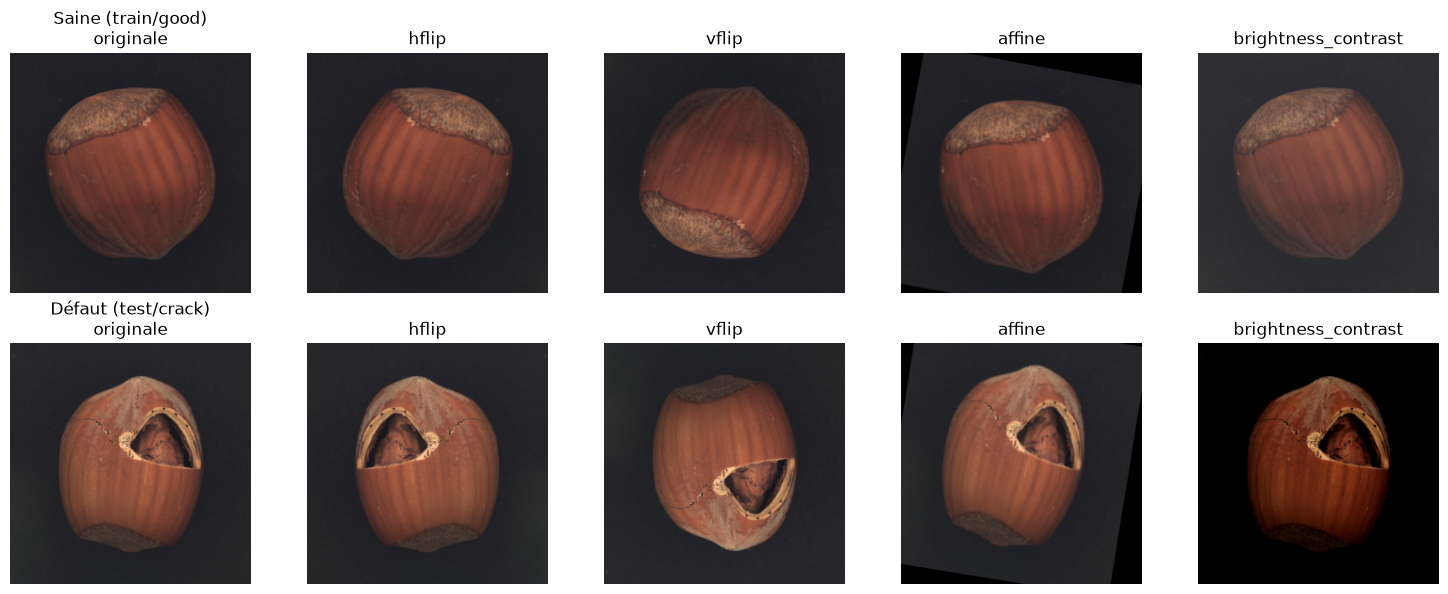

In [32]:
import matplotlib.pyplot as plt

# Une image saine et une défectueuse (redimensionnées)
samples = {
    "Saine (train/good)": sorted((RESIZED_DIR / "train" / "good").glob("*.png"))[0],
    "Défaut (test/crack)": sorted((RESIZED_DIR / "test" / "crack").glob("*.png"))[0],
}

n_cols = len(transforms) + 1
fig, axes = plt.subplots(len(samples), n_cols, figsize=(3 * n_cols, 3 * len(samples)))

for row, (label, path) in enumerate(samples.items()):
    img_bgr = cv2.imread(str(path))  # BGR uint8 (transfos appliquées comme à la sauvegarde)

    # Originale (BGR -> RGB pour l'affichage)
    axes[row][0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[row][0].set_title(f"{label}\noriginale")
    axes[row][0].axis("off")

    # Une vignette par transformation nommée
    for col, (name, tf) in enumerate(transforms.items(), start=1):
        aug = tf(image=img_bgr)["image"]
        axes[row][col].imshow(cv2.cvtColor(aug, cv2.COLOR_BGR2RGB))
        axes[row][col].set_title(name)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()